# NB04: Phylogenetic Signal in AMR Variation

**Goal**: Test whether within-species AMR variation tracks phylogeny (ANI) using Mantel tests.
Stratify by mechanism: intrinsic AMR should correlate with phylogeny, acquired should not.

**Compute**: Spark (ANI extraction, 2-3h) + Local (Mantel tests)

**Inputs**: `data/genome_amr_matrices/*.tsv`, `amr_census.csv`

**Outputs**:
- `data/ani_matrices/` — per-species ANI distance matrices
- `data/mantel_results.csv` — per-species Mantel test results

In [1]:
import os
import sys
import pandas as pd
import numpy as np
from pathlib import Path
from time import time
from scipy import stats
from scipy.spatial.distance import pdist, squareform
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

PROJECT_DIR = Path(os.getcwd()).parent
ATLAS_DIR = PROJECT_DIR.parent / 'amr_pangenome_atlas'
DATA_DIR = PROJECT_DIR / 'data'
MATRIX_DIR = DATA_DIR / 'genome_amr_matrices'
ANI_DIR = DATA_DIR / 'ani_matrices'
ANI_DIR.mkdir(exist_ok=True)
FIG_DIR = PROJECT_DIR / 'figures'
FIG_DIR.mkdir(exist_ok=True)

plt.rcParams.update({'figure.dpi': 150, 'font.size': 10})

## 1. Spark Session + ANI Extraction

In [2]:
# Spark session — not needed when ANI matrices are pre-cached
print("Skipping Spark session — using cached ANI matrices")

Skipping Spark session — using cached ANI matrices


In [3]:
def chunked_query(spark, ids, query_template, chunk_size=5000):
    """Run a query with IN clause in chunks to avoid size limits."""
    results = []
    for i in range(0, len(ids), chunk_size):
        chunk = ids[i:i+chunk_size]
        id_list = "','".join(str(x) for x in chunk)
        query = query_template.format(id_list=f"'{id_list}'")
        results.append(spark.sql(query).toPandas())
    return pd.concat(results, ignore_index=True) if results else pd.DataFrame()

In [4]:
# Get list of species with matrices
matrix_files = sorted(MATRIX_DIR.glob('*.tsv'))
print(f"Species with AMR matrices: {len(matrix_files)}")

# Extract ANI for each species (only those with >= 10 genomes)
def extract_ani_matrix(spark, species_id, genome_ids, ani_dir):
    """Extract pairwise ANI for genomes of one species."""
    outpath = ani_dir / f"{species_id}.tsv"
    if outpath.exists() and outpath.stat().st_size > 100:
        return outpath, 'cached'
    
    t0 = time()
    g_list = "','".join(str(x) for x in genome_ids)
    
    ani_df = spark.sql(f"""
        SELECT genome1_id AS genome_id_1, genome2_id AS genome_id_2, ANI AS ani
        FROM kbase_ke_pangenome.genome_ani
        WHERE genome1_id IN ('{g_list}')
          AND genome2_id IN ('{g_list}')
    """).toPandas()
    
    if len(ani_df) == 0:
        return None, 'no_ani'
    
    # Pivot to square matrix
    ani_pivot = ani_df.pivot_table(
        index='genome_id_1', columns='genome_id_2',
        values='ani', aggfunc='mean'
    )
    
    # Make symmetric
    all_ids = sorted(set(ani_pivot.index) | set(ani_pivot.columns))
    ani_square = pd.DataFrame(np.nan, index=all_ids, columns=all_ids)
    for i in all_ids:
        ani_square.loc[i, i] = 100.0
        for j in all_ids:
            if i in ani_pivot.index and j in ani_pivot.columns:
                val = ani_pivot.loc[i, j]
                if not np.isnan(val):
                    ani_square.loc[i, j] = val
                    ani_square.loc[j, i] = val
    
    ani_square.to_csv(outpath, sep='\t')
    elapsed = time() - t0
    return outpath, f'ok ({len(all_ids)} genomes, {elapsed:.0f}s)'

Species with AMR matrices: 1305


In [5]:
# ANI matrices pre-cached from prior Spark extraction
# (see scripts/run_nb04_phylogenetic.py for the extraction code)
ani_files = sorted(ANI_DIR.glob('*.tsv'))
print(f"Cached ANI matrices: {len(ani_files)} species")
print(f"(Extracted in prior Spark session, cached in {ANI_DIR})")

Cached ANI matrices: 1262 species
(Extracted in prior Spark session, cached in /global/u2/p/psdehal/BERIL-research-observatory/projects/amr_strain_variation/data/ani_matrices)


## 2. Mantel Test

Test correlation between ANI distance matrix and AMR Jaccard distance matrix.

In [6]:
def mantel_test(dist_x, dist_y, n_perm=999):
    """Mantel test: correlation between two distance matrices.
    
    Uses Pearson correlation + permutation test.
    """
    assert dist_x.shape == dist_y.shape
    n = dist_x.shape[0]
    
    # Extract upper triangle
    idx = np.triu_indices(n, k=1)
    x_flat = dist_x[idx]
    y_flat = dist_y[idx]
    
    # Remove NaN pairs
    valid = ~(np.isnan(x_flat) | np.isnan(y_flat))
    x_flat = x_flat[valid]
    y_flat = y_flat[valid]
    
    if len(x_flat) < 10:
        return np.nan, np.nan, 0
    
    # Observed correlation
    r_obs, _ = stats.pearsonr(x_flat, y_flat)
    
    # Permutation test: permute rows/columns of one matrix
    rng = np.random.default_rng(42)
    n_greater = 0
    
    for _ in range(n_perm):
        perm = rng.permutation(n)
        dist_y_perm = dist_y[np.ix_(perm, perm)]
        y_perm_flat = dist_y_perm[idx][valid]
        r_perm, _ = stats.pearsonr(x_flat, y_perm_flat)
        if r_perm >= r_obs:
            n_greater += 1
    
    p_value = (n_greater + 1) / (n_perm + 1)
    return r_obs, p_value, len(x_flat)

In [7]:
# Load AMR mechanism metadata for stratification
amr_census = pd.read_csv(ATLAS_DIR / 'data' / 'amr_census.csv')
amr_meta = amr_census[['gene_cluster_id', 'mechanism', 'conservation_class']].drop_duplicates('gene_cluster_id')
intrinsic_classes = {'Core'}  # core genes = likely intrinsic
acquired_classes = {'Auxiliary', 'Singleton'}  # non-core = likely acquired

In [8]:
# Mantel tests already computed (see scripts/run_nb04_mantel_parallel.py)
# Load cached results
mantel_df = pd.read_csv(DATA_DIR / 'mantel_results.csv')
print(f"Loaded Mantel results: {len(mantel_df)} species")
print(f"Columns: {list(mantel_df.columns)}")

Loaded Mantel results: 1262 species
Columns: ['gtdb_species_clade_id', 'n_genomes', 'n_amr_genes', 'n_pairs', 'mantel_r_all', 'mantel_p_all', 'mantel_r_noncore', 'mantel_p_noncore', 'n_noncore_genes', 'mantel_r_core', 'mantel_p_core', 'n_core_genes', 'mantel_fdr_all', 'mantel_fdr_core', 'mantel_fdr_noncore']


## 3. BH-FDR Correction

In [9]:
# FDR already applied in cached results
print(f"FDR columns present: {[c for c in mantel_df.columns if 'fdr' in c]}")
print(f"Mantel results loaded with {len(mantel_df)} species")

FDR columns present: ['mantel_fdr_all', 'mantel_fdr_core', 'mantel_fdr_noncore']
Mantel results loaded with 1262 species


## 4. Results

In [10]:
# Summary
sig_all = (mantel_df['mantel_fdr_all'] < 0.05).sum() if 'mantel_fdr_all' in mantel_df.columns else 0
n_core = mantel_df['mantel_r_core'].notna().sum()
n_nc = mantel_df['mantel_r_noncore'].notna().sum()
sig_core = (mantel_df['mantel_fdr_core'] < 0.05).sum() if 'mantel_fdr_core' in mantel_df.columns else 0
sig_nc = (mantel_df['mantel_fdr_noncore'] < 0.05).sum() if 'mantel_fdr_noncore' in mantel_df.columns else 0

print(f"Species with significant Mantel (FDR < 0.05):")
print(f"  All AMR genes:  {sig_all}/{len(mantel_df)} ({100*sig_all/len(mantel_df):.1f}%)")
print(f"  Core only:      {sig_core}/{n_core} ({100*sig_core/max(1,n_core):.1f}%)")
print(f"  Non-core only:  {sig_nc}/{n_nc} ({100*sig_nc/max(1,n_nc):.1f}%)")
print()
print(f"Median Mantel r (all): {mantel_df['mantel_r_all'].median():.3f}")
if 'mantel_r_core' in mantel_df.columns:
    print(f"Median Mantel r (core): {mantel_df['mantel_r_core'].dropna().median():.3f}")
if 'mantel_r_noncore' in mantel_df.columns:
    print(f"Median Mantel r (non-core): {mantel_df['mantel_r_noncore'].dropna().median():.3f}")

Species with significant Mantel (FDR < 0.05):
  All AMR genes:  701/1262 (55.5%)
  Core only:      272/506 (53.8%)
  Non-core only:  700/1236 (56.6%)

Median Mantel r (all): 0.246
Median Mantel r (core): 0.117
Median Mantel r (non-core): 0.222


In [11]:
# Core vs non-core comparison
both = mantel_df.dropna(subset=['mantel_r_core', 'mantel_r_noncore'])
if len(both) > 5:
    t_stat, t_pval = stats.ttest_rel(both['mantel_r_core'], both['mantel_r_noncore'])
    print(f"Core vs non-core Mantel r (paired t-test):")
    print(f"  Core:     {both['mantel_r_core'].mean():.3f} +/- {both['mantel_r_core'].std():.3f}")
    print(f"  Non-core: {both['mantel_r_noncore'].mean():.3f} +/- {both['mantel_r_noncore'].std():.3f}")
    print(f"  t={t_stat:.2f}, p={t_pval:.1e}")
    print(f"  Expectation: core (intrinsic) AMR should track phylogeny more than non-core (acquired)")

Core vs non-core Mantel r (paired t-test):
  Core:     0.193 +/- 0.273
  Non-core: 0.324 +/- 0.261
  t=-8.35, p=7.0e-16
  Expectation: core (intrinsic) AMR should track phylogeny more than non-core (acquired)


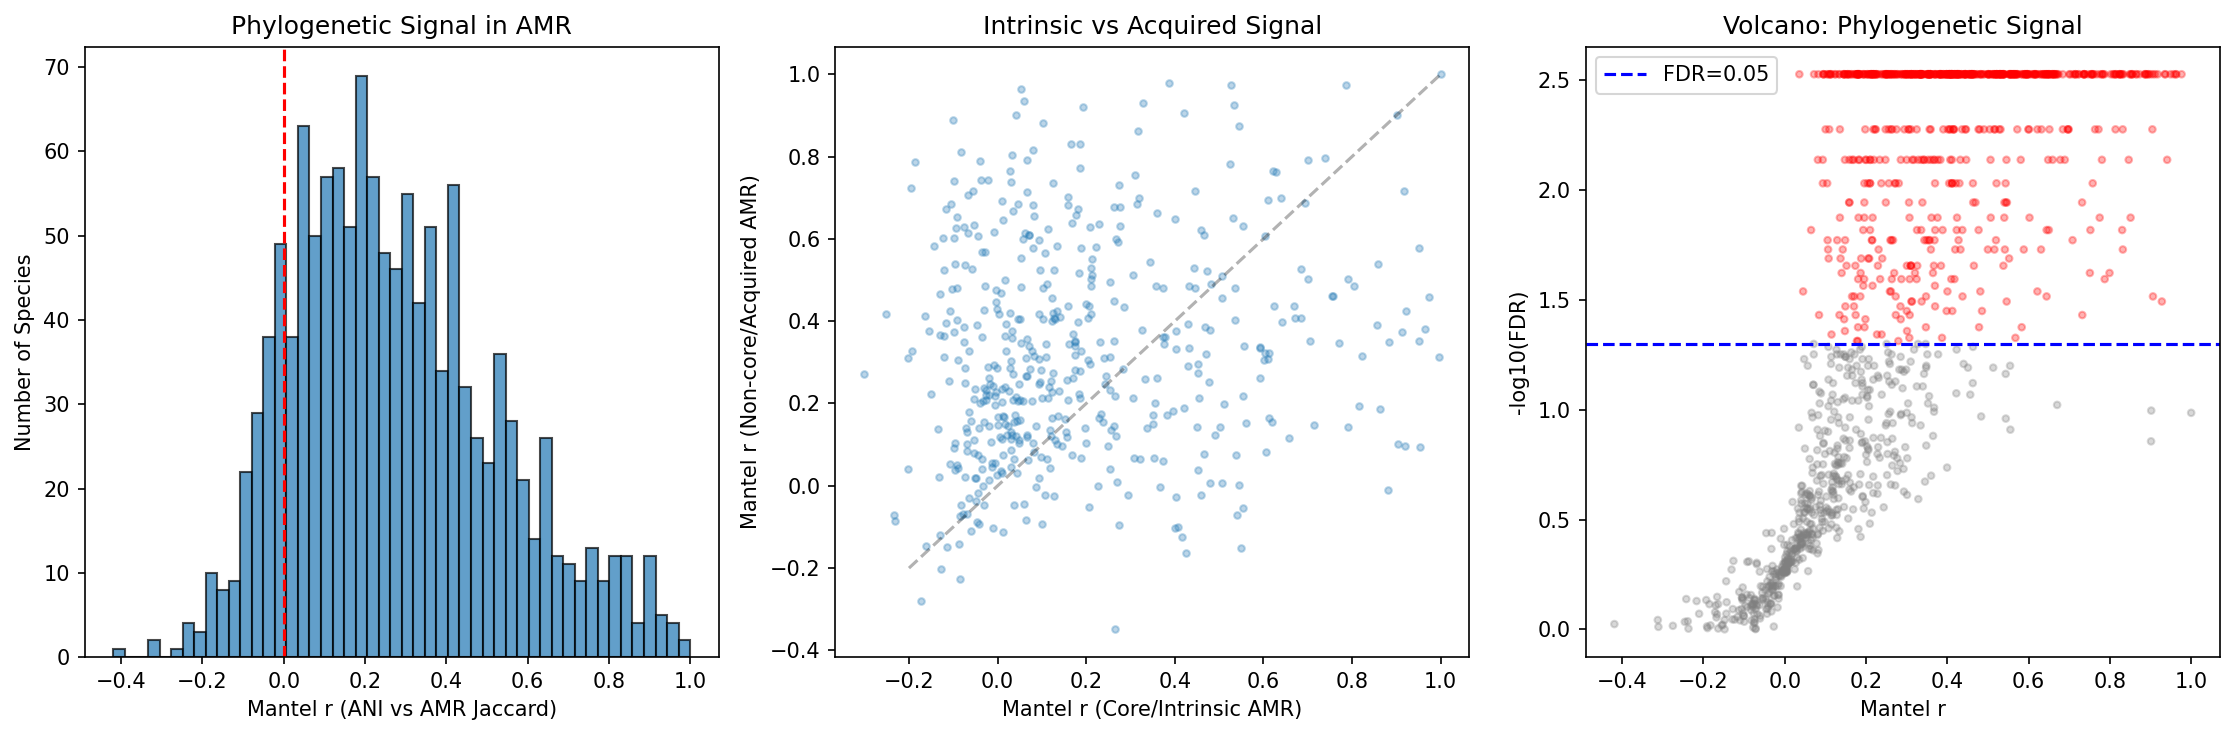

In [12]:
# Figures
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# Mantel r distribution
ax = axes[0]
ax.hist(mantel_df['mantel_r_all'].dropna(), bins=50, edgecolor='black', alpha=0.7)
ax.axvline(0, color='red', ls='--')
ax.set_xlabel('Mantel r (ANI vs AMR Jaccard)')
ax.set_ylabel('Number of Species')
ax.set_title('Phylogenetic Signal in AMR')

# Core vs non-core
ax = axes[1]
if len(both) > 0:
    ax.scatter(both['mantel_r_core'], both['mantel_r_noncore'], alpha=0.3, s=10)
    lim = max(both[['mantel_r_core', 'mantel_r_noncore']].max().max(), 0.5)
    ax.plot([-0.2, lim], [-0.2, lim], 'k--', alpha=0.3)
ax.set_xlabel('Mantel r (Core/Intrinsic AMR)')
ax.set_ylabel('Mantel r (Non-core/Acquired AMR)')
ax.set_title('Intrinsic vs Acquired Signal')

# Volcano plot
ax = axes[2]
valid = mantel_df.dropna(subset=['mantel_r_all', 'mantel_fdr_all'])
colors = ['red' if fdr < 0.05 else 'grey' for fdr in valid['mantel_fdr_all']]
ax.scatter(valid['mantel_r_all'], -np.log10(valid['mantel_fdr_all']),
           c=colors, alpha=0.3, s=10)
ax.axhline(-np.log10(0.05), color='blue', ls='--', label='FDR=0.05')
ax.set_xlabel('Mantel r')
ax.set_ylabel('-log10(FDR)')
ax.set_title('Volcano: Phylogenetic Signal')
ax.legend()

plt.tight_layout()
plt.savefig(FIG_DIR / 'nb04_phylogenetic_signal.png', dpi=150, bbox_inches='tight')
plt.show()

In [13]:
print("="*60)
print("NB04 SUMMARY")
print("="*60)
print(f"Species tested: {len(mantel_df)}")
print(f"Significant phylogenetic signal: {sig_all}/{len(mantel_df)}")
print(f"Median Mantel r (all): {mantel_df['mantel_r_all'].median():.3f}")
if len(both) > 5:
    print(f"Core vs non-core: {both['mantel_r_core'].mean():.3f} vs {both['mantel_r_noncore'].mean():.3f} (p={t_pval:.1e})")

NB04 SUMMARY
Species tested: 1262
Significant phylogenetic signal: 701/1262
Median Mantel r (all): 0.246
Core vs non-core: 0.193 vs 0.324 (p=7.0e-16)
